# PHLOWER Trajectory Analysis — NK Compartment

**Project**: P697 TEAseq T1D Low-Dose IL-2

**Date**: 2026-04-03

**Objective**: Test the hypothesis that NK cells follow an out-and-back trajectory
from Baseline through treatment (Post-IL2 → Post-RAPA) and back to Followup,
using Hodge Laplacian decomposition (PHLOWER).

**Input**: `data/outputData/scenic_export_NK/` (exported from `P697_DA.rmd`)
— Uses combined WNN embedding (RNA harmony dims 1:18 + ATAC LSI harmony dims 1:29)
to capture both transcriptomic and chromatin information.

**Environment**: `phlower_env` conda environment (see `code/phlower_environment.yml`)

## 0. Setup

In [2]:
import os
import time
import pickle
from datetime import datetime

import numpy as np
import pandas as pd
import scipy.io
import scipy.sparse
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import colorcet as cc

import phlower

import session_info

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (8, 6)

print(f"phlower {phlower.__version__}")
print(f"scanpy {sc.__version__}")
print(f"anndata {ad.__version__}")

/home/tedwards/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-ehovudiu because there was an issue with the default path (/home/tedwards/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


phlower 0.1.5
scanpy 1.11.5
anndata 0.11.4


In [3]:
# --- Paths ---
COMP = "NK"
PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
EXPORT_DIR = os.path.join(PROJECT_DIR, "data", "outputData", f"scenic_export_{COMP}")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "data", "outputData", "phlower")
TABLE_DIR = os.path.join(PROJECT_DIR, "tables")
FIG_DIR = os.path.join(PROJECT_DIR, "figures", "phlower")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

TODAY = datetime.today().strftime("%Y-%m-%d")
print(f"Compartment: {COMP}")
print(f"Export dir:  {EXPORT_DIR}")
print(f"Output dir:  {OUTPUT_DIR}")
print(f"Date stamp:  {TODAY}")

Compartment: NK
Export dir:  /home/tedwards/projects/P697_TEAseq_T1D_low_dose_IL2/data/outputData/scenic_export_NK
Output dir:  /home/tedwards/projects/P697_TEAseq_T1D_low_dose_IL2/data/outputData/phlower
Date stamp:  2026-04-04


## 1. Load Data & Construct AnnData

In [4]:
# --- RNA counts (sparse) ---
rna_counts = scipy.io.mmread(os.path.join(EXPORT_DIR, "RNA_counts.mtx")).T.tocsr()
rna_genes = pd.read_csv(os.path.join(EXPORT_DIR, "RNA_genes.txt"), header=None)[0].values
rna_barcodes = pd.read_csv(os.path.join(EXPORT_DIR, "RNA_barcodes.txt"), header=None)[0].values

print(f"RNA matrix: {rna_counts.shape[0]} cells x {rna_counts.shape[1]} genes")
assert rna_counts.shape == (len(rna_barcodes), len(rna_genes))

# --- ATAC counts (sparse) ---
atac_counts = scipy.io.mmread(os.path.join(EXPORT_DIR, "ATAC_counts.mtx")).T.tocsr()
atac_peaks = pd.read_csv(os.path.join(EXPORT_DIR, "ATAC_peaks.txt"), header=None)[0].values
atac_barcodes = pd.read_csv(os.path.join(EXPORT_DIR, "ATAC_barcodes.txt"), header=None)[0].values

print(f"ATAC matrix: {atac_counts.shape[0]} cells x {atac_counts.shape[1]} peaks")
assert atac_counts.shape == (len(atac_barcodes), len(atac_peaks))
assert np.array_equal(rna_barcodes, atac_barcodes), "RNA and ATAC barcodes must match"

RNA matrix: 21656 cells x 27715 genes
ATAC matrix: 21656 cells x 60219 peaks


In [5]:
# --- Metadata ---
meta = pd.read_csv(os.path.join(EXPORT_DIR, "metadata.csv"), index_col=0)
meta.index.name = None

# Rename Washout → Followup if needed (scenic_export may predate rename)
if "Washout" in meta["treatmentPhase"].values:
    meta["treatmentPhase"] = meta["treatmentPhase"].replace("Washout", "Followup")
    print("Renamed Washout → Followup")

# Ensure consistent ordering
meta = meta.loc[rna_barcodes]

# Diagnostic: cells per donor × treatment phase
print("\nCells per donor × treatmentPhase:")
ct = pd.crosstab(meta["donorID"], meta["treatmentPhase"])
print(ct)
print(f"\nTotal cells: {len(meta)}")

# Flag any donors missing Baseline
if "Baseline" in ct.columns:
    missing_bl = ct.index[ct["Baseline"] == 0].tolist()
    if missing_bl:
        print(f"\n⚠ Donor(s) missing Baseline: {missing_bl} — their cells won't be roots")


Cells per donor × treatmentPhase:
treatmentPhase  Baseline  Followup  Post-IL2  Post-RAPA
donorID                                                
1                   1097      1102       622        702
2                      0       647       384        457
3                   1006       930       772        419
5                    866       896       519        193
6                    330       348       263        332
7                    833       973       481        519
8                   1272      1109       653        930
9                   1160       997       679        165

Total cells: 21656

⚠ Donor(s) missing Baseline: [2] — their cells won't be roots


In [6]:
# --- Embeddings ---
emb_harmony = pd.read_csv(os.path.join(EXPORT_DIR, "embedding_harmony.csv"), index_col=0)
emb_harmony_lsi = pd.read_csv(os.path.join(EXPORT_DIR, "embedding_harmony_lsi.csv"), index_col=0)
emb_umap = pd.read_csv(os.path.join(EXPORT_DIR, "embedding_umap.wnn.csv"), index_col=0)

# Match WNN configuration: RNA harmony dims 1:18, ATAC LSI harmony dims 1:29
N_RNA_HARMONY_DIMS = 18   # TODO: TUNABLE — must match WNN dims.list for RNA
N_ATAC_LSI_DIMS = 29      # TODO: TUNABLE — must match WNN dims.list for ATAC

harmony_rna_arr = emb_harmony.loc[rna_barcodes].values[:, :N_RNA_HARMONY_DIMS]
harmony_lsi_arr = emb_harmony_lsi.loc[rna_barcodes].values[:, :N_ATAC_LSI_DIMS]
umap_arr = emb_umap.loc[rna_barcodes].values

# Concatenate RNA + ATAC embeddings for combined WNN input
wnn_combined = np.hstack([harmony_rna_arr, harmony_lsi_arr])
N_WNN_DIMS = wnn_combined.shape[1]

print(f"RNA harmony embedding:  {harmony_rna_arr.shape} (first {N_RNA_HARMONY_DIMS} of {emb_harmony.shape[1]})")
print(f"ATAC LSI embedding:     {harmony_lsi_arr.shape} (first {N_ATAC_LSI_DIMS} of {emb_harmony_lsi.shape[1]})")
print(f"Combined WNN embedding: {wnn_combined.shape}")
print(f"UMAP embedding:         {umap_arr.shape}")

RNA harmony embedding:  (21656, 18) (first 18 of 30)
ATAC LSI embedding:     (21656, 29) (first 29 of 49)
Combined WNN embedding: (21656, 47)
UMAP embedding:         (21656, 2)


In [7]:
# --- Construct AnnData ---
adata = ad.AnnData(
    X=rna_counts,
    obs=meta,
    var=pd.DataFrame(index=rna_genes),
)
adata.obsm["X_pca"] = wnn_combined       # Combined WNN embedding for PHLOWER
adata.obsm["X_harmony_rna"] = harmony_rna_arr
adata.obsm["X_harmony_lsi"] = harmony_lsi_arr
adata.obsm["X_umap"] = umap_arr

# Ensure categorical types
adata.obs["treatmentPhase"] = pd.Categorical(
    adata.obs["treatmentPhase"],
    categories=["Baseline", "Post-IL2", "Post-RAPA", "Followup"],
    ordered=True,
)
adata.obs["wnn_clusters"] = adata.obs["wnn_clusters"].astype(str).astype("category")
adata.obs["donorID"] = adata.obs["donorID"].astype(str).astype("category")

print(adata)
print(f"\nobsm keys: {list(adata.obsm.keys())}")

AnnData object with n_obs × n_vars = 21656 × 27715
    obs: 'donorID', 'visitNum', 'treatmentPhase', 'wnn_clusters', 'RNA.weight', 'ATAC.weight'
    obsm: 'X_pca', 'X_harmony_rna', 'X_harmony_lsi', 'X_umap'

obsm keys: ['X_pca', 'X_harmony_rna', 'X_harmony_lsi', 'X_umap']


## 2. DDHodge Pseudotime

In [8]:
# --- Define root cells (Baseline) ---
roots = (adata.obs["treatmentPhase"] == "Baseline").values.tolist()
n_roots = sum(roots)
print(f"Root cells (Baseline): {n_roots} / {adata.n_obs} ({100*n_roots/adata.n_obs:.1f}%)")

Root cells (Baseline): 6564 / 21656 (30.3%)


In [9]:
# --- DDHodge ---
# TODO: TUNABLE PARAMETERS
#   k    : kNN bandwidth (default 11, higher = smoother graph)
#   npc  : number of PCs to use (we use N_WNN_DIMS combined RNA+ATAC components)
#   ndc  : number of diffusion components (default 40)
#   s    : diffusion time scale (default 1)

t0 = time.time()
print(f"Starting ddhodge at {datetime.now().strftime('%H:%M:%S')}...")
print(f"Using combined WNN embedding: {N_WNN_DIMS} dims ({N_RNA_HARMONY_DIMS} RNA + {N_ATAC_LSI_DIMS} ATAC)")

phlower.ext.ddhodge(
    adata,
    basis="X_pca",
    roots=roots,
    k=11,               # TODO: TUNABLE
    npc=N_WNN_DIMS,     # TODO: TUNABLE — match the combined WNN dims
    ndc=40,             # TODO: TUNABLE
    s=1,                # TODO: TUNABLE
)

elapsed = time.time() - t0
print(f"ddhodge completed in {elapsed/60:.1f} min")

Starting ddhodge at 00:59:08...
Using combined WNN embedding: 47 dims (18 RNA + 29 ATAC)
2026-04-04 00:59:08.261882 distance_matrix


2026-04-04 01:02:00.345752 Diffusionmaps: 
done.
2026-04-04 01:05:09.285181 diffusion distance:
2026-04-04 01:06:46.357739 transition matrix:
2026-04-04 01:07:24.186708 graph from A
2026-04-04 01:07:26.182906 Rewiring: 
2026-04-04 01:07:26.183133 div(g_o)...
2026-04-04 01:10:29.798503 edge weight...
2026-04-04 01:10:32.440355 cholesky solve ax=b...
+ 1e-06 I is positive-definite
2026-04-04 01:12:00.817334 grad...
2026-04-04 03:01:28.102263 potential.
2026-04-04 05:05:05.924880 ddhodge done.
done.
2026-04-04 05:05:07.150835 calculate layouts
2026-04-04 05:37:55.953005 done
ddhodge completed in 278.8 min


## 3. Pseudotime Diagnostics

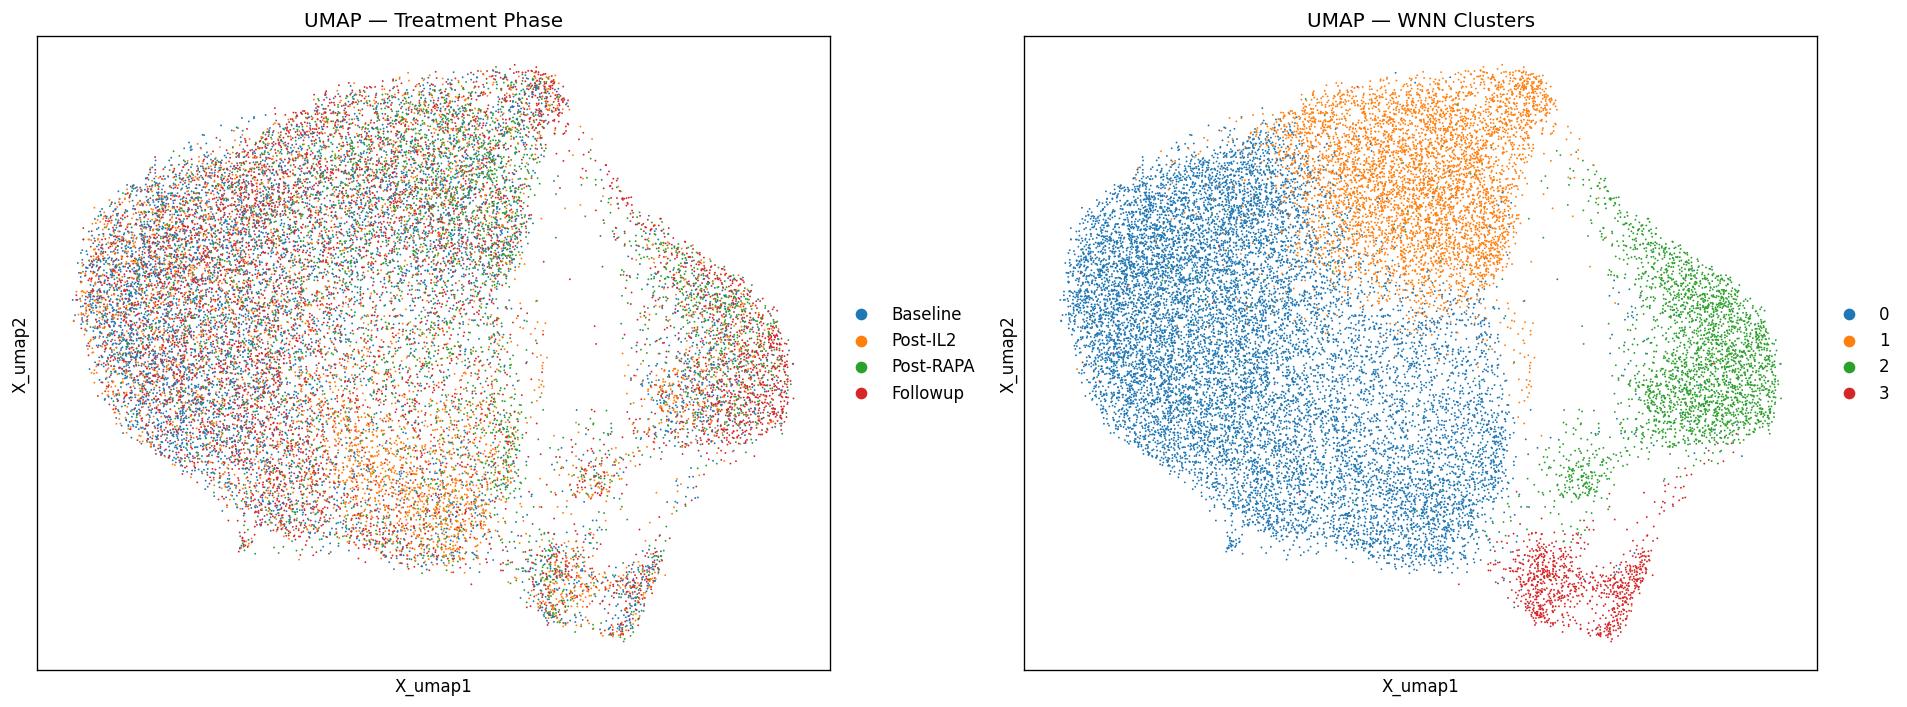

In [10]:
# UMAP colored by treatment phase and WNN clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, title in zip(axes, ["treatmentPhase", "wnn_clusters"],
                           ["Treatment Phase", "WNN Clusters"]):
    sc.pl.embedding(adata, basis="X_umap", color=col, ax=ax, show=False,
                    frameon=True, title=f"UMAP — {title}", size=5)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"phlower_{COMP}_umap_overview.pdf"), bbox_inches="tight")
plt.show()

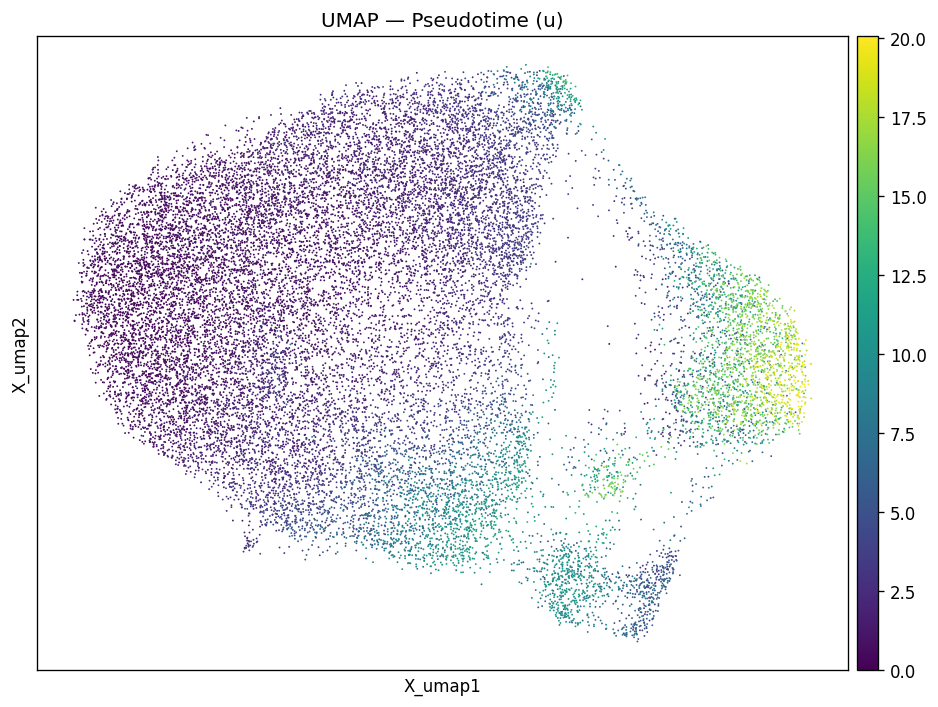

In [11]:
# UMAP colored by pseudotime
# First transfer pseudotime from graph nodes to adata.obs
phlower.tl.assign_graph_node_attr_to_adata(adata, from_attr="u", to_attr="u")

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sc.pl.embedding(adata, basis="X_umap", color="u", ax=ax, show=False,
                frameon=True, title="UMAP — Pseudotime (u)", size=5,
                color_map="viridis")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"phlower_{COMP}_pseudotime_umap.pdf"), bbox_inches="tight")
plt.show()

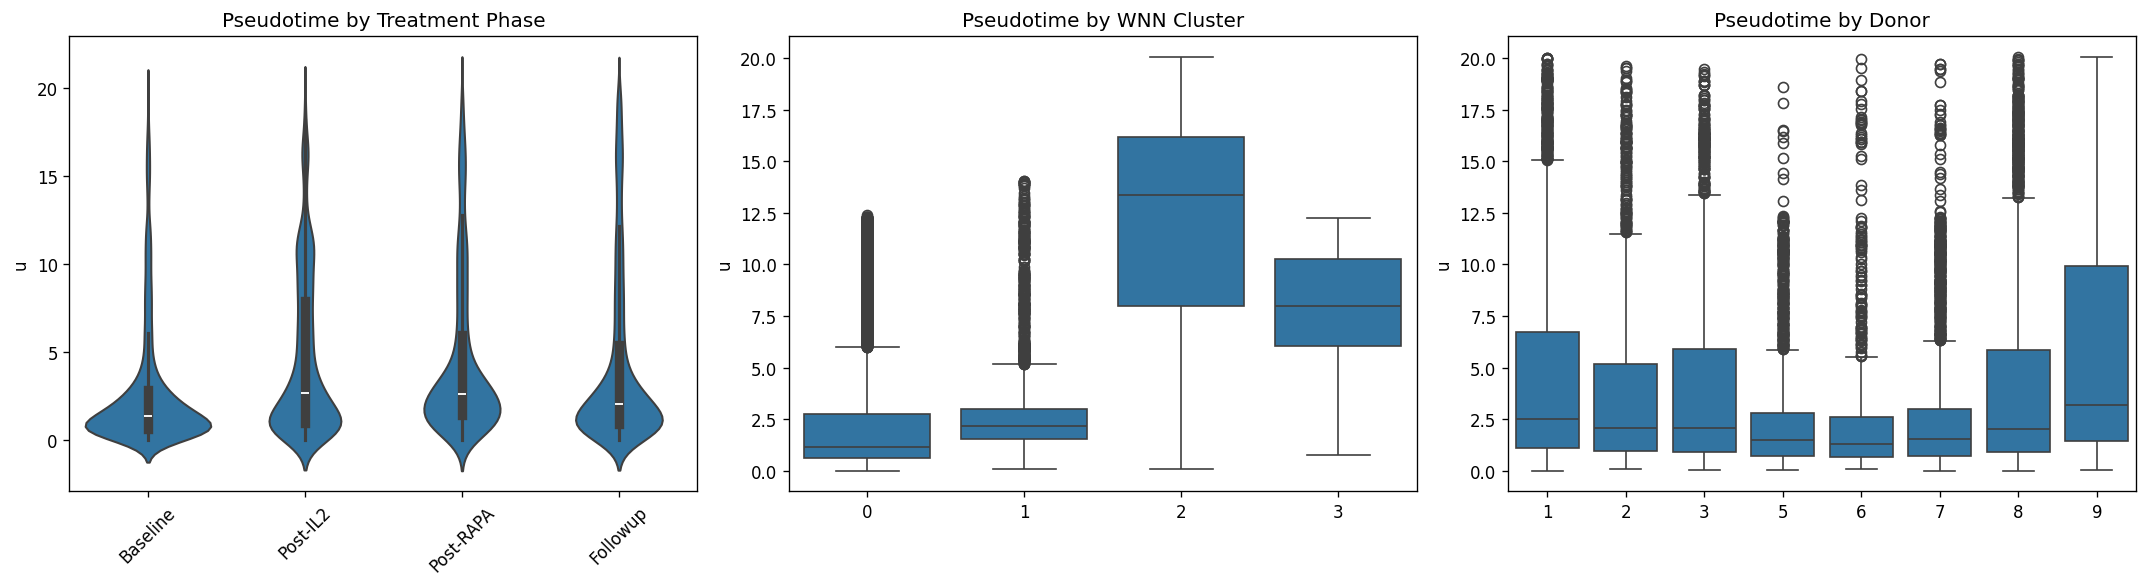

In [12]:
# Pseudotime distribution by treatment phase
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By treatment phase
phase_order = ["Baseline", "Post-IL2", "Post-RAPA", "Followup"]
sns.violinplot(
    data=adata.obs, x="treatmentPhase", y="u",
    order=phase_order, ax=axes[0], inner="box",
)
axes[0].set_title("Pseudotime by Treatment Phase")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=45)

# By WNN cluster
cluster_order = sorted(adata.obs["wnn_clusters"].unique(), key=lambda x: int(x) if x.isdigit() else x)
sns.boxplot(
    data=adata.obs, x="wnn_clusters", y="u",
    order=cluster_order, ax=axes[1],
)
axes[1].set_title("Pseudotime by WNN Cluster")
axes[1].set_xlabel("")

# By donor
sns.boxplot(
    data=adata.obs, x="donorID", y="u",
    ax=axes[2],
)
axes[2].set_title("Pseudotime by Donor")
axes[2].set_xlabel("")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"phlower_{COMP}_pseudotime_distributions.pdf"), bbox_inches="tight")
plt.show()

## 4. Delaunay Triangulation

In [13]:
# TODO: TUNABLE PARAMETERS
#   start_n       : number of start nodes (default 5)
#   end_n         : number of end nodes (default 5)
#   circle_quant  : quantile for circle detection (default 0.1)
#   trunc_quantile: truncation quantile for long edges (default 0.75)

t0 = time.time()
print(f"Starting Delaunay triangulation at {datetime.now().strftime('%H:%M:%S')}...")

phlower.tl.construct_delaunay(
    adata,
    cluster_name="wnn_clusters",
    node_attr="u",
    start_n=10,          # TODO: TUNABLE
    end_n=10,            # TODO: TUNABLE
    circle_quant=0.1,    # TODO: TUNABLE
    trunc_quantile=0.75, # TODO: TUNABLE
    calc_layout=True,
)

elapsed = time.time() - t0
print(f"Delaunay completed in {elapsed:.1f} s")

Starting Delaunay triangulation at 05:38:04...
start clusters  ['0', '1', '2']
end clusters  ['0', '1', '3', '2']


Delaunay completed in 4115.8 s


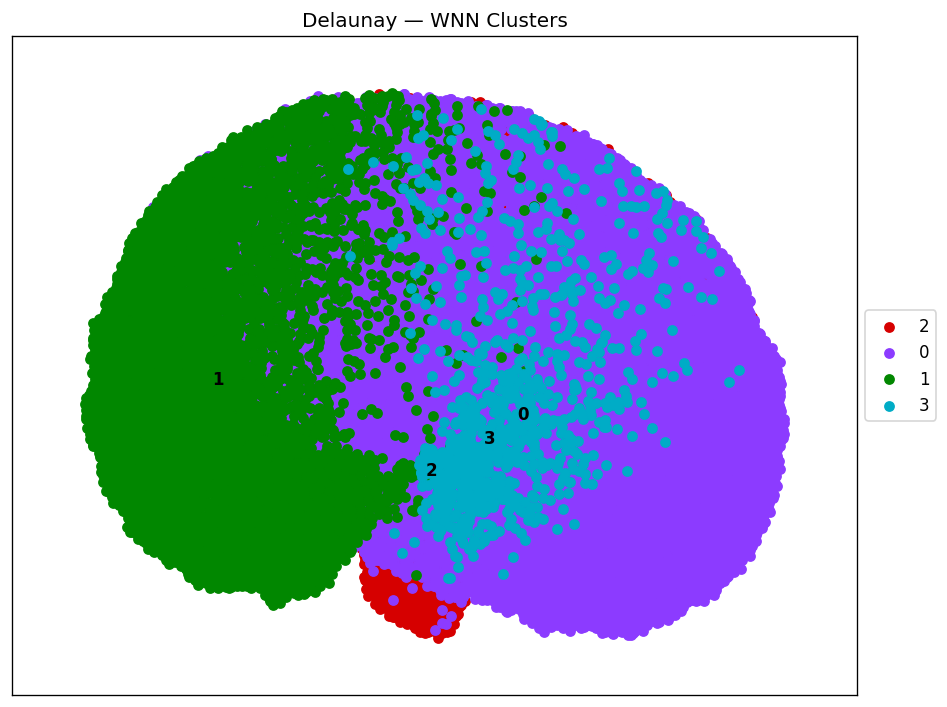

In [14]:
# Visualize Delaunay graph colored by WNN clusters
# Keys are auto-generated from graph_basis: "{basis}_ddhodge_g_triangulation_circle"
tri_graph = adata.uns["graph_basis"] + "_triangulation_circle"
tri_layout = tri_graph  # layout stored in obsm under same key

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

phlower.pl.nxdraw_group(
    adata,
    graph_name=tri_graph,
    layout_name=tri_layout,
    group_name="wnn_clusters",
    ax=ax,
    node_size=30,
)
ax.set_title("Delaunay — WNN Clusters")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"phlower_{COMP}_delaunay_clusters.pdf"), bbox_inches="tight")
plt.show()

## 5. Hodge Laplacian Decomposition

In [15]:
t0 = time.time()
print(f"Starting L1 Hodge Laplacian decomposition at {datetime.now().strftime('%H:%M:%S')}...")

phlower.tl.L1Norm_decomp(adata)

elapsed = time.time() - t0
print(f"L1Norm_decomp completed in {elapsed:.1f} s")

Starting L1 Hodge Laplacian decomposition at 06:46:49...


803.3843140602112  sec
L1Norm_decomp completed in 805.2 s


knee eigen value is  14


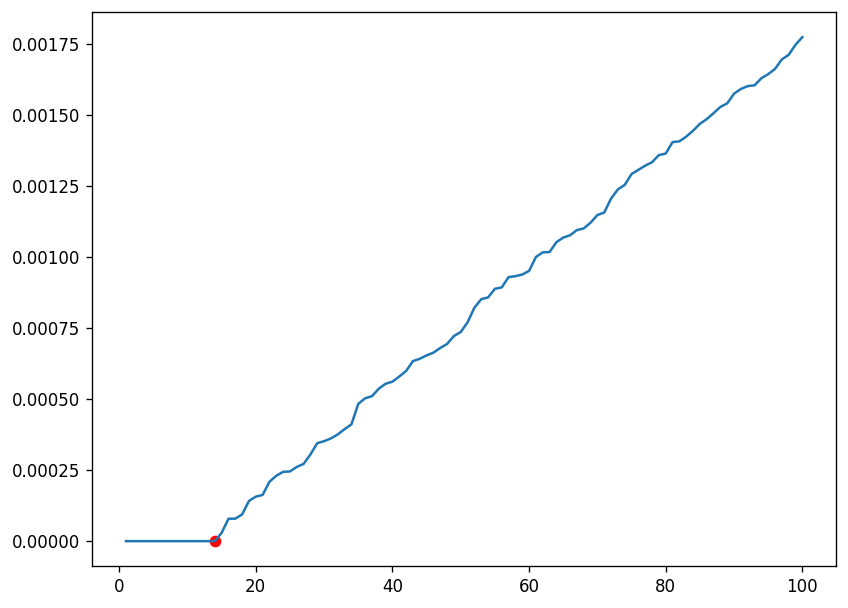

In [16]:
# Knee point detection for eigenvalues
phlower.tl.knee_eigen(adata, plot=True)

plt.savefig(os.path.join(FIG_DIR, f"phlower_{COMP}_knee_eigen.pdf"), bbox_inches="tight")
plt.show()

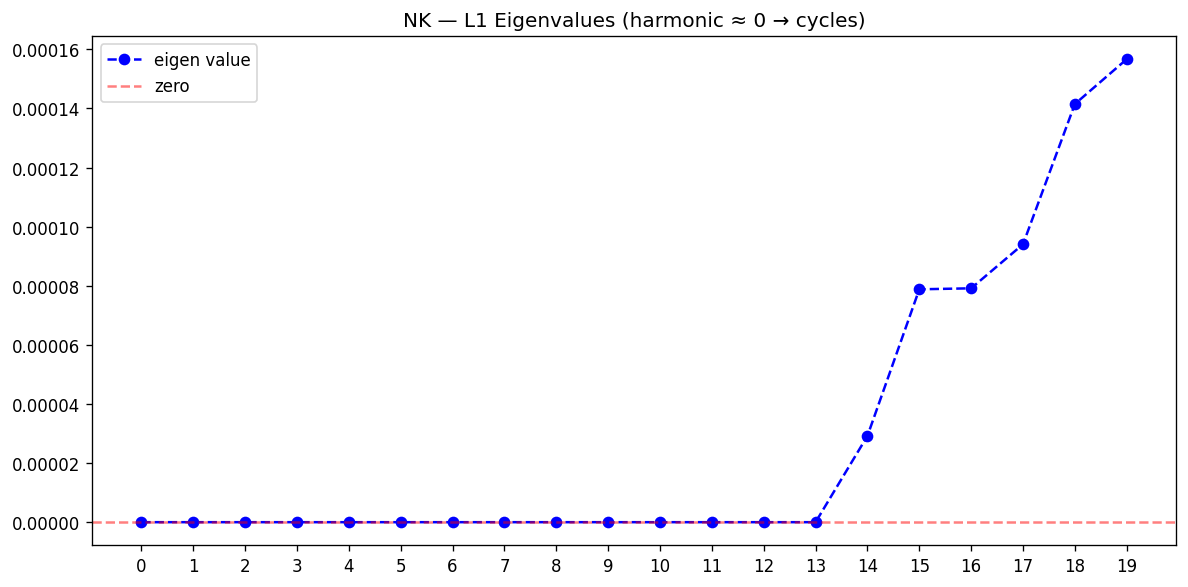

In [17]:
# Eigenvalue line plot — KEY READOUT
# Eigenvalues ≈ 0 indicate harmonic components (cycles)
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
phlower.pl.plot_eigen_line(adata, n_eig=20, ax=ax)
ax.set_title(f"{COMP} — L1 Eigenvalues (harmonic ≈ 0 → cycles)")
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='zero')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"phlower_{COMP}_eigenvalues.pdf"), bbox_inches="tight")
plt.show()

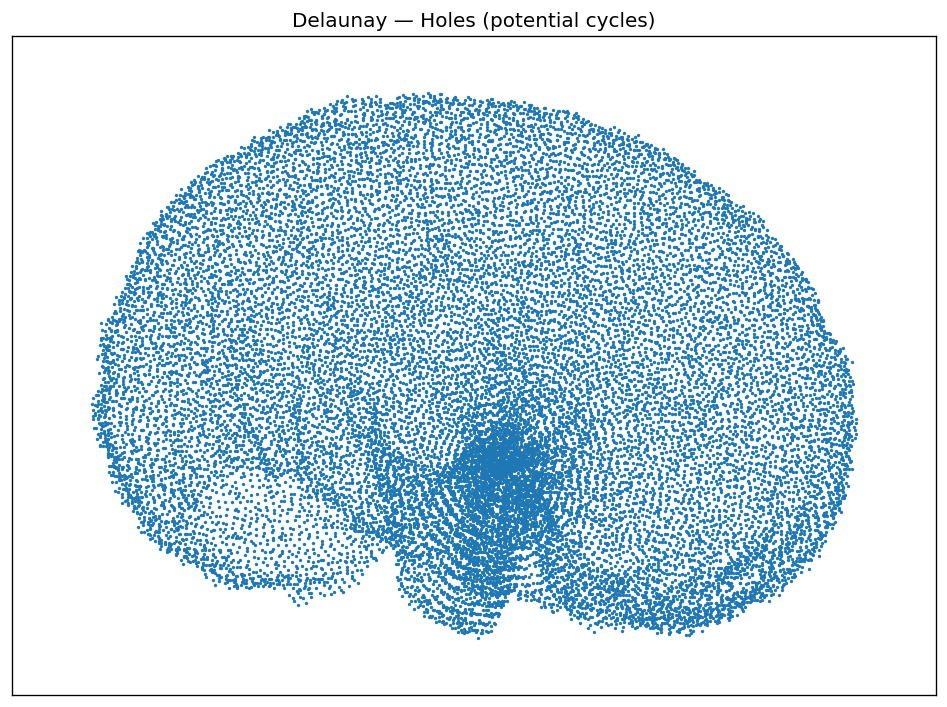

In [18]:
# Delaunay graph with holes (requires L1Norm_decomp)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

phlower.pl.nxdraw_holes(
    adata,
    ax=ax,
)
ax.set_title("Delaunay — Holes (potential cycles)")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"phlower_{COMP}_delaunay_holes.pdf"), bbox_inches="tight")
plt.show()

## 6. Random Walk Trajectories

In [19]:
# TODO: TUNABLE PARAMETERS
#   n : number of random walk trajectories (default 10000)

t0 = time.time()
print(f"Starting random walk at {datetime.now().strftime('%H:%M:%S')}...")

phlower.tl.random_climb_knn(
    adata,
    n=10000,  # TODO: TUNABLE
)

elapsed = time.time() - t0
print(f"Random walk completed in {elapsed:.1f} s")

Starting random walk at 07:00:32...


100%|██████████| 10000/10000 [01:06<00:00, 150.07it/s]

Random walk completed in 192.3 s


## 7. Trajectory Projection & Clustering

In [20]:
t0 = time.time()
print(f"Starting trajectory matrix at {datetime.now().strftime('%H:%M:%S')}...")

phlower.tl.trajs_matrix(adata)

elapsed = time.time() - t0
print(f"Trajectory matrix completed in {elapsed:.1f} s")

Starting trajectory matrix at 07:03:45...
2026-04-04 07:03:45.285384 projecting trajectories to simplics...


2026-04-04 07:04:20.336180 Embedding trajectory harmonics...
eigen_n < 1, use knee_eigen to find the number of eigen vectors to use: 14


/home/tedwards/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2026-04-04 07:05:35.579401 done.
Trajectory matrix completed in 110.3 s


In [21]:
# TODO: TUNABLE — eps for DBSCAN clustering
phlower.tl.trajs_clustering(
    adata,
    eps=0.5,  # TODO: TUNABLE
)

# Show trajectory cluster sizes
if "trajs_clusters" in adata.uns:
    clusters = adata.uns["trajs_clusters"]
    from collections import Counter
    counts = Counter(clusters)
    print("Trajectory cluster sizes:")
    for k, v in sorted(counts.items()):
        print(f"  Cluster {k}: {v} trajectories")

Trajectory cluster sizes:
  Cluster 0: 9993 trajectories
  Cluster 1: 7 trajectories


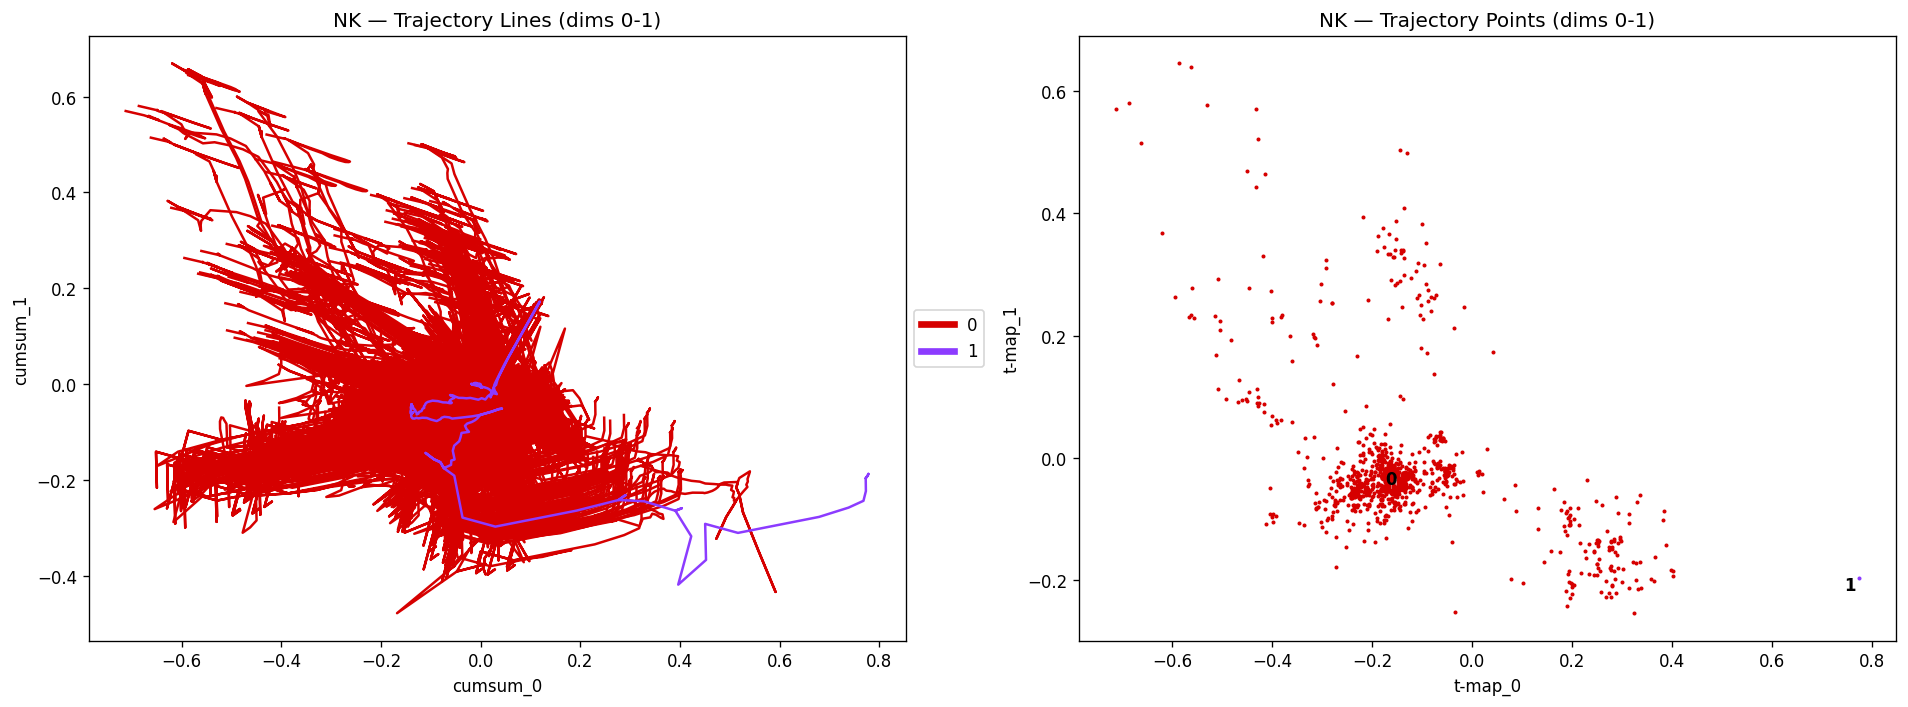

In [22]:
# Trajectory lines in harmonic space (2D)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

phlower.pl.plot_trajectory_harmonic_lines(
    adata,
    dims=[0, 1],
    ax=axes[0],
    sample_ratio=0.1,
)
axes[0].set_title(f"{COMP} — Trajectory Lines (dims 0-1)")

phlower.pl.plot_trajectory_harmonic_points(
    adata,
    dims=[0, 1],
    ax=axes[1],
    sample_ratio=0.1,
)
axes[1].set_title(f"{COMP} — Trajectory Points (dims 0-1)")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"phlower_{COMP}_trajectories_harmonic.pdf"), bbox_inches="tight")
plt.show()

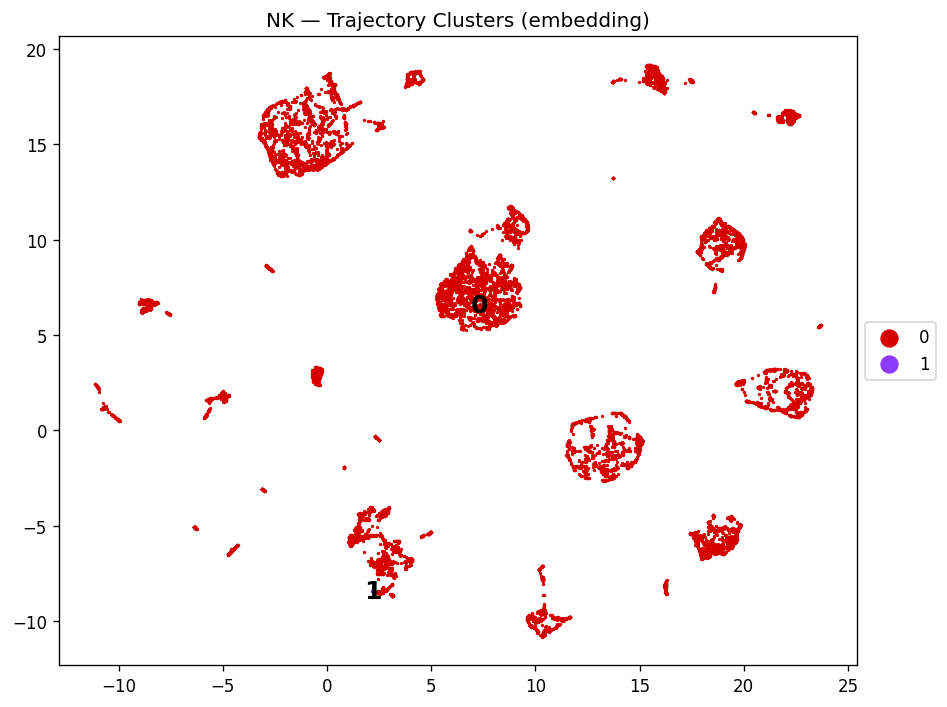

In [23]:
# Trajectory embedding (dimensionality reduction of trajectory space)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

phlower.pl.plot_trajs_embedding(
    adata,
    ax=ax,
)
ax.set_title(f"{COMP} — Trajectory Clusters (embedding)")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"phlower_{COMP}_trajs_embedding.pdf"), bbox_inches="tight")
plt.show()

## 8. Stream Tree

In [24]:
# TODO: TUNABLE PARAMETERS
#   min_bin_number : minimum cells per bin (default 5)
#   cut_threshold  : threshold for cutting branches (default 1)

t0 = time.time()
print(f"Starting harmonic stream tree at {datetime.now().strftime('%H:%M:%S')}...")

phlower.tl.harmonic_stream_tree(
    adata,
    cluster="wnn_clusters",
    min_bin_number=20,  # TODO: TUNABLE
    cut_threshold=1,    # TODO: TUNABLE
)

elapsed = time.time() - t0
print(f"Stream tree completed in {elapsed:.1f} s")

Starting harmonic stream tree at 07:06:34...
eigen_n < 1, use knee_eigen to find the number of eigen vectors to use
eigen_n: 14


{np.int64(0), np.int64(1)}


traj bins: 100%|██████████| 2/2 [00:45<00:00, 22.96s/it]


[(np.int64(0), np.int64(1))]


edges projection: 100%|██████████| 10000/10000 [00:26<00:00, 383.28it/s]


there are 37 nodes not visited in the tree
will approximate the node cumsum coordinate by 5 nearest accessible neighbors
Stream tree completed in 195.6 s


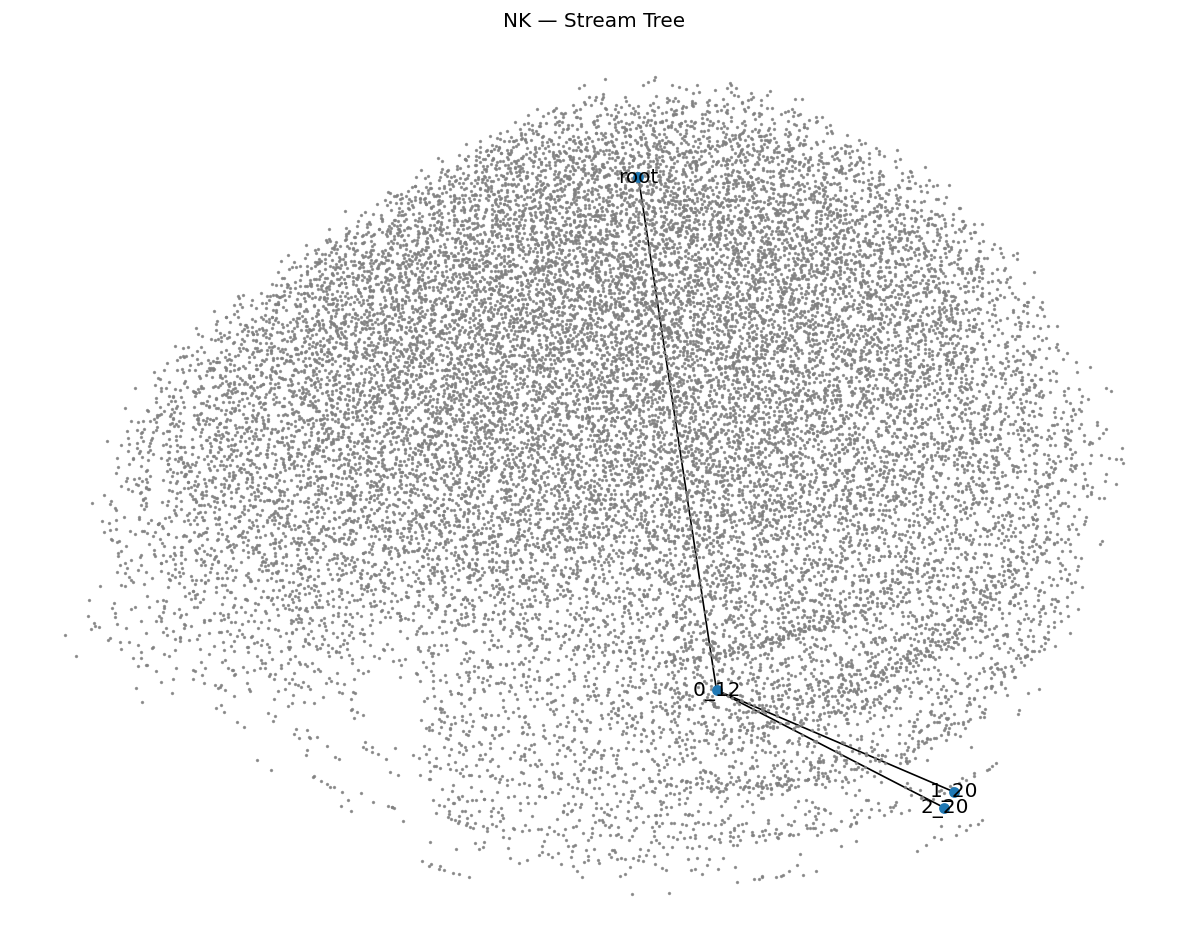

In [25]:
# Stream tree embedding
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
phlower.pl.plot_stream_tree_embedding(adata, ax=ax)
ax.set_title(f"{COMP} — Stream Tree")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"phlower_{COMP}_stream_tree.pdf"), bbox_inches="tight")
plt.show()

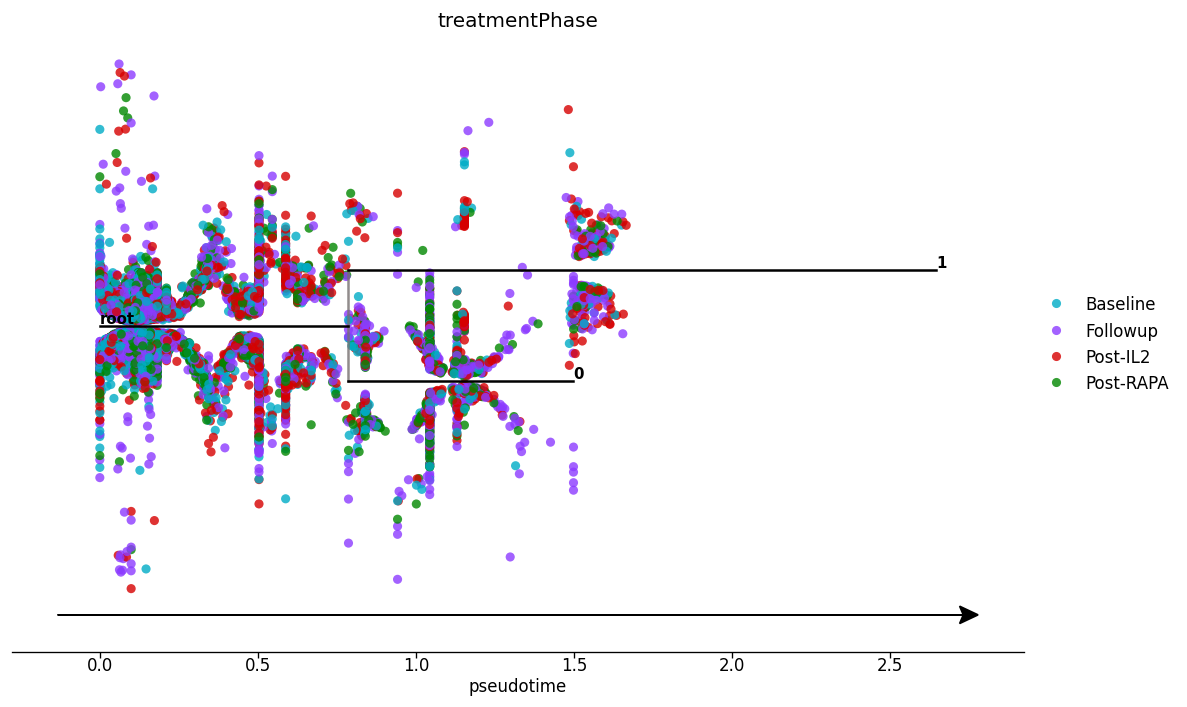

In [26]:
# Stream plot colored by treatment phase
phlower.ext.plot_stream_sc(
    adata,
    color=["treatmentPhase"],
    fig_size=(10, 6),
)
plt.savefig(os.path.join(FIG_DIR, f"phlower_{COMP}_stream_sc_treatmentPhase.pdf"), bbox_inches="tight")
plt.show()

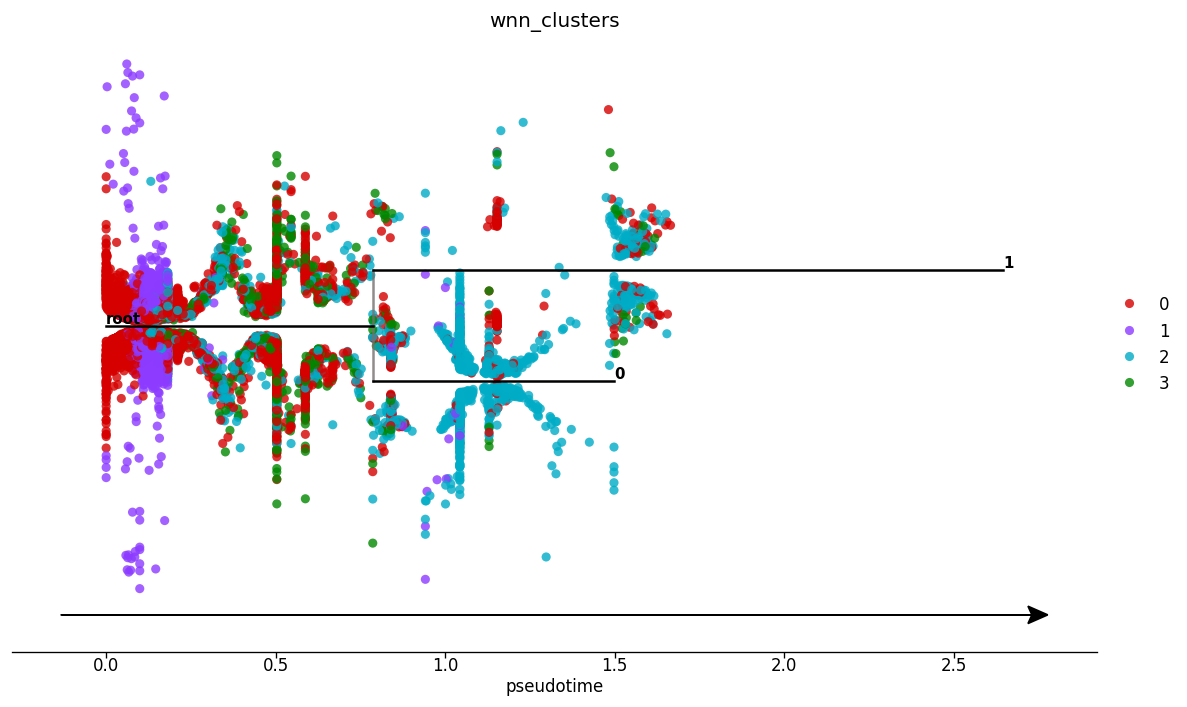

In [27]:
# Stream plot colored by WNN clusters
phlower.ext.plot_stream_sc(
    adata,
    color=["wnn_clusters"],
    fig_size=(10, 6),
)
plt.savefig(os.path.join(FIG_DIR, f"phlower_{COMP}_stream_sc_wnn_clusters.pdf"), bbox_inches="tight")
plt.show()

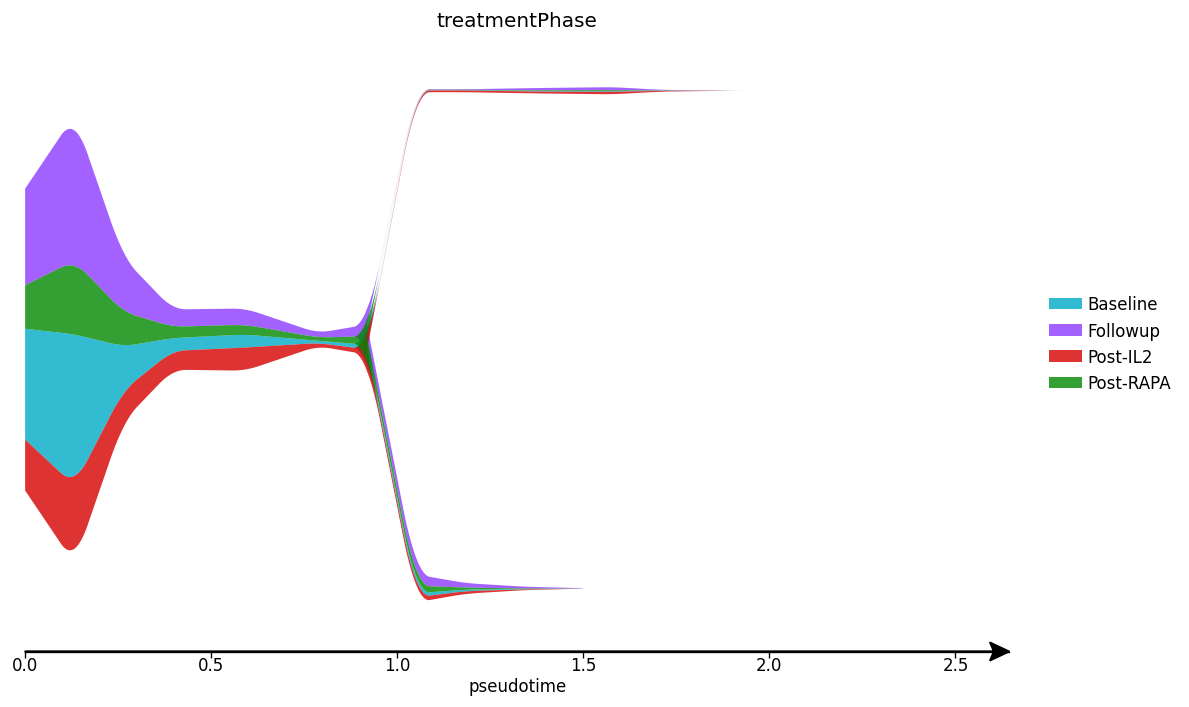

In [28]:
# Smooth stream plot by treatment phase
phlower.ext.plot_stream(
    adata,
    color=["treatmentPhase"],
    fig_size=(10, 6),
)
plt.savefig(os.path.join(FIG_DIR, f"phlower_{COMP}_stream_treatmentPhase.pdf"), bbox_inches="tight")
plt.show()

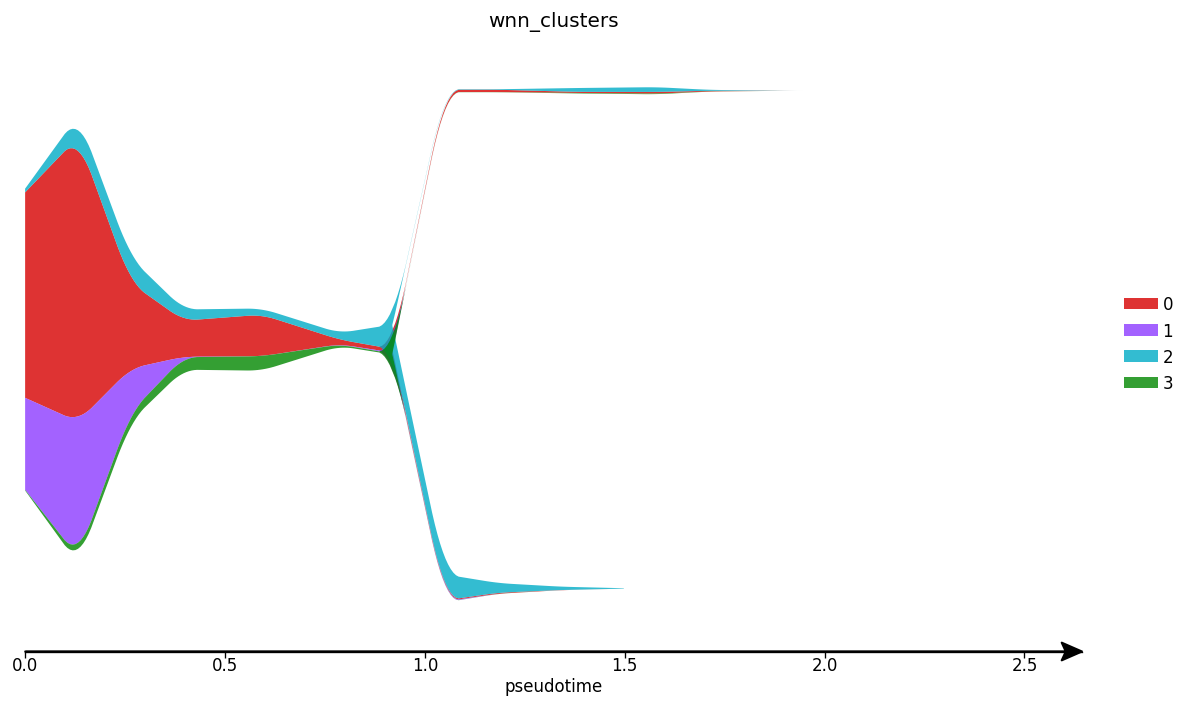

In [29]:
# Smooth stream plot by WNN clusters
phlower.ext.plot_stream(
    adata,
    color=["wnn_clusters"],
    fig_size=(10, 6),
)
plt.savefig(os.path.join(FIG_DIR, f"phlower_{COMP}_stream_wnn_clusters.pdf"), bbox_inches="tight")
plt.show()

## 9. Save Results

In [30]:
# Save full AnnData as pickle
pickle_path = os.path.join(OUTPUT_DIR, f"phlower_{COMP}_{TODAY}.pickle")
with open(pickle_path, "wb") as f:
    pickle.dump(adata, f)
print(f"Saved: {pickle_path}")

# Export pseudotime + trajectory assignments as CSV
export_df = adata.obs[["donorID", "visitNum", "treatmentPhase", "wnn_clusters"]].copy()
if "u" in adata.obs.columns:
    export_df["pseudotime_u"] = adata.obs["u"]

csv_path = os.path.join(TABLE_DIR, f"phlower_{COMP}_{TODAY}_pseudotime.csv")
export_df.to_csv(csv_path)
print(f"Saved: {csv_path}")

Saved: /home/tedwards/projects/P697_TEAseq_T1D_low_dose_IL2/data/outputData/phlower/phlower_NK_2026-04-04.pickle
Saved: /home/tedwards/projects/P697_TEAseq_T1D_low_dose_IL2/tables/phlower_NK_2026-04-04_pseudotime.csv


## 10. Session Info

In [31]:
session_info.show()